In [2]:
from torch.utils.data import DataLoader
from timm.optim import create_optimizer_v2
from swa_orchestrator import SWAorchestrator
from models import LSTM, STGCN, GCN_LSTM
from utils import *

#   local   #
dir_path = ''

pemsbay = 'PEMS-BAY'
pemsbay_kag = "scchuy/pemsbay"
pemsbay_pkl = 'adj_mx_bay.pkl'
pemsbay_h5 = 'pems-bay.h5'

loss_name = 'MSE'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
data_graph_dict = load_and_preprocess(pemsbay, pemsbay_kag, pemsbay_pkl, pemsbay_h5, key='speed')
data_dict, graph_dict = data_graph_dict['data'], data_graph_dict['graph']

100%|██████████| 29.9M/29.9M [00:00<00:00, 125MB/s] 

Extracting files...


PEMS-BAY graph loaded with 325 sensors
Data aggregated into 5min intervals
Imputing missing values
Implementing a 70%-10%-20% split


In [4]:
window_dict = {}

for key, val in data_dict.items():
    if isinstance(val, np.ndarray):
        window_dict[key] = make_windows(val)

In [5]:
X_train, y_train = window_dict['train']['X'], window_dict['train']['y']
X_val, y_val = window_dict['val']['X'], window_dict['val']['y']
X_test, y_test = window_dict['test']['X'], window_dict['test']['y']

X_train.shape

(36475, 12, 325)

In [6]:
batch_size = 64

train_loader = DataLoader(TrafficDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TrafficDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TrafficDataset(X_test,  y_test), batch_size=batch_size)

In [11]:
num_sensors = len(graph_dict['sensors'])
max_epochs = 250

configs = {

    'STGCN': {
        'class': STGCN,
        'params': {
            'adj_matrix': graph_dict['adj_matrix'],
            'input_size': 1,
            'hidden_size': 64,
            'gcn_channels': 16,
            'num_layers': 2,
            'horizon': 3,
            'output_size': 1,
            'dropout': 0.1
        },
        'lr': .005,
        'warmup_t': 10,
        't_initial': 30
    },

}

In [12]:
criterion = nn.HuberLoss() if loss_name == 'Huber' else nn.MSELoss()

encyclopedia = {}
metrics = []

for name, conf in configs.items():
    model = conf['class'](**conf['params']).to(device)

    optimizer = create_optimizer_v2(
        model,
        opt='sgd',
        lr=conf['lr'],
        momentum=0.9,
        weight_decay=1e-4,
        filter_bias_and_bn=True
    )

    orchestrator = SWAorchestrator(
        model,
        optimizer=optimizer,
        warmup_t=conf['warmup_t'],
        t_initial=conf['t_initial']
      )

    encyclopedia[name] = {}

    history = train_model(
        model_name = name,
        epochs = max_epochs,
        criterion = criterion,
        optimizer = optimizer,
        scheduler = orchestrator,
        model = model,
        train_loader = train_loader,
        val_loader = val_loader,
        device = device
    )

    encyclopedia[name]['history'] = history

    swa_model = orchestrator.swa_model
    encyclopedia[name]['swa_model'] = swa_model

    _, preds_inv, targets_inv = evaluate(criterion, test_loader, swa_model, device, scaler=data_dict['scaler'])

    encyclopedia[name]['preds'] = preds_inv
    encyclopedia[name]['labels'] = targets_inv

    metrics.append(get_metrics(name, preds_inv, targets_inv))

    del model, optimizer, orchestrator
    torch.cuda.empty_cache()

Training the STGCN
Epoch 1 [SGD] | Loss: 2.0326 | Val loss: 2.6535
> New best model
Epoch 2 [SGD] | Loss: 2.0234 | Val loss: 2.6439
> New best model
Epoch 3 [SGD] | Loss: 0.2657 | Val loss: 0.2047
> New best model
Epoch 4 [SGD] | Loss: 0.1461 | Val loss: 0.1796
> New best model
Epoch 5 [SGD] | Loss: 0.1321 | Val loss: 0.1689
> New best model
Epoch 6 [SGD] | Loss: 0.1257 | Val loss: 0.1636
> New best model
Epoch 7 [SGD] | Loss: 0.1218 | Val loss: 0.1595
> New best model
Epoch 8 [SGD] | Loss: 0.1191 | Val loss: 0.1561
> New best model
Epoch 9 [SGD] | Loss: 0.1170 | Val loss: 0.1535
> New best model
Epoch 10 [SGD] | Loss: 0.1154 | Val loss: 0.1522
> New best model
Epoch 11 [SGD] | Loss: 0.1143 | Val loss: 0.1500
> New best model
Epoch 12 [SGD] | Loss: 0.1133 | Val loss: 0.1488
> New best model
Epoch 13 [SGD] | Loss: 0.1119 | Val loss: 0.1479
> New best model
Epoch 14 [SGD] | Loss: 0.1109 | Val loss: 0.1465
> New best model
Epoch 15 [SGD] | Loss: 0.1100 | Val loss: 0.1455
> New best model


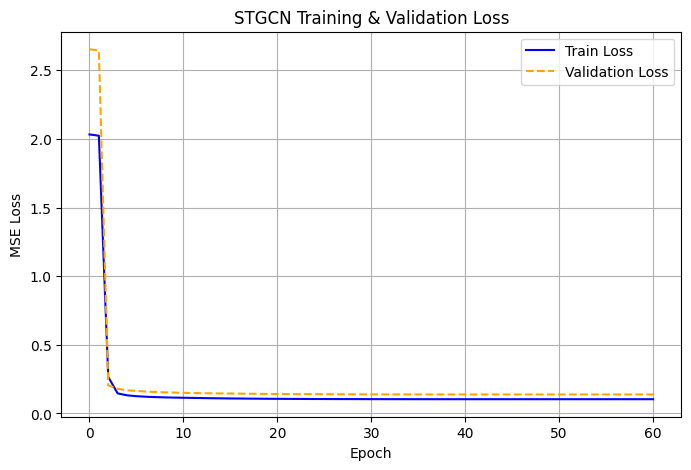

In [13]:
for name in encyclopedia.keys():
    history = encyclopedia[name]['history']
    plot_training_history(pemsbay, name, history, loss_name + ' Loss', dir_path)

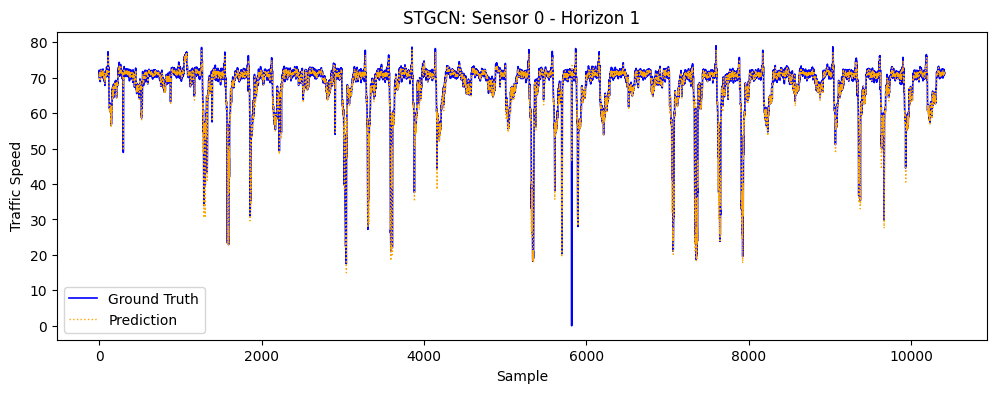

In [14]:
for name in encyclopedia.keys():
    preds = encyclopedia[name]['preds']
    labels = encyclopedia[name]['labels']

    plot_sample(name, 0, 0, preds, labels, dir_path)

In [15]:
metrics_df = pd.concat(metrics, axis=1)
metrics_df.round(4)

,STGCN
MSE,6.8260
MAE,1.3166
WAPE,2.1077
